In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_datadicts_from_db
from ase.io import read,write
from ase.db import connect
from sklearn.manifold import TSNE
import random


In [2]:
def populate_classes(
        log_rate_dist:np.array,
        num_classes:int=100,
        max_samples_per_class:int=100
    ):
    min_rate = np.min(log_rate_dist)
    max_rate = np.max(log_rate_dist)
    class_divisions = np.linspace(min_rate, max_rate, num_classes)
    class_indices = np.digitize(log_rate_dist, class_divisions)
    total_rate_list = []
    num_per_class = []
    for i in range(num_classes):
        indices = np.argwhere(class_indices==i+1)
        num_in_class = len(indices)
        num_per_class.append(num_in_class)
        if num_in_class > max_samples_per_class:
            store_indices = np.random.permutation(indices)[0:max_samples_per_class]
        else:
            store_indices = indices
        for store_index in store_indices:
                total_rate_list.append(log_rate_dist[store_index])
    print(np.sum(num_per_class[1:])+100)
    return np.array(total_rate_list).squeeze()

def filter_dataset(
        atoms_list:list,
        num_classes:int=100,
        max_samples_per_class:int=100,
        use_log:bool=True,
        log_rate_offset:float=1e-2
    ):

    rates = np.array([atoms.info["rate"] for atoms in atoms_list])
    if use_log:
        rates = np.log(rates)
        if log_rate_offset is not None:
            min_rate = np.log(np.exp(np.min(rates))+log_rate_offset)
    else:
        min_rate = np.min(rates)
    max_rate = np.max(rates)
    class_divisions = np.linspace(min_rate, max_rate, num_classes)
    class_indices = np.digitize(rates, class_divisions)
    filtered_atoms_list = []
    for idx in range(num_classes):
        indices = np.argwhere(class_indices==idx+1)
        n_samples_in_class, _ = indices.shape
        if n_samples_in_class > max_samples_per_class:
            store_indices = np.random.permutation(indices.squeeze())[:max_samples_per_class]
        else:
            store_indices = indices.squeeze(axis=-1)
        for store_index in store_indices:
            filtered_atoms_list.append(atoms_list[store_index])
    return filtered_atoms_list
   

In [15]:
atoms_list = read("../datasets/genetic_alg/no_duplicates.traj", index=":")

filtered_atoms_list = atoms_list#filter_dataset(
#    atoms_list=atoms_list,
#    max_samples_per_class=100,
#    log_rate_offset=1e-3
#)

train_datadicts = [{"elements":atoms.get_chemical_symbols(), "rate":atoms.info["rate"]} for atoms in filtered_atoms_list]
train_rates = np.log10(np.array([atoms.info["rate"] for atoms in filtered_atoms_list]))
print(train_rates)

[0.02725381 0.39652858 0.33660614 ... 1.3857763  0.83596248 1.33549099]


0.951473742654115
1.3083793559884902
0.5192443299526943
0.2767049627561048


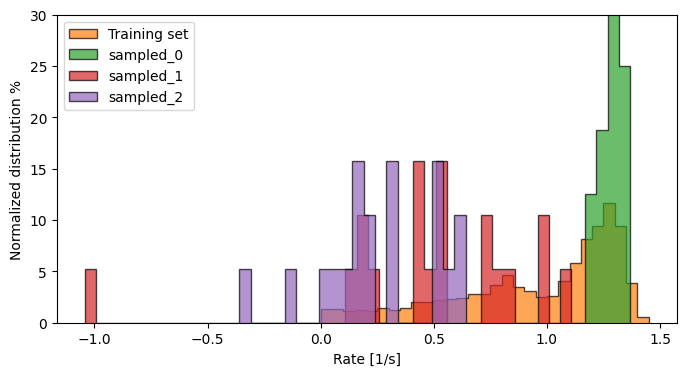

In [17]:
sample_dist_list = []
samples_pth = "reproduce_old/model_001/samples"
num_dbs = 3
for i in range(num_dbs):
    database = Database.establish_connection(
        filename=f"joint_evals_{i+1}.db",
        pth_header=samples_pth
        )
    datadicts = load_datadicts_from_db(database=database)
    sampled_rates = np.log10(np.array([datadict["rate"] for datadict in datadicts]))
    sample_dist_list.append(sampled_rates)
    rate_max_sampled = np.max(sampled_rates)
    #print(rate_max_sampled)


fig, ax = plt.subplots(figsize=(8,4))
rate_interval = 0.05
i = 0
hist_prior = None
y_lims = 0.3*100
labels = ["Training set"]

#ax.vlines(x=np.linspace(rate_min, rate_max, 50),ymin=0.0, ymax=y_lims)

step = 2.5
for rates, color, label in zip([train_rates]+sample_dist_list, ["C1"]+[f"C{i+2}" for i in range(num_dbs)], labels+[f"sampled_{i}" for i in range(num_dbs)]):
    print(np.mean(rates))
    rate_min, rate_max = np.min(rates), np.max(rates)
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    #ax.set_xlim([-0.5, 400.0])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

In [ ]:
database = Database.establish_connection(
        filename=f"test_opt.db",
        pth_header="../../results/optimization/genetic_algorithm"
        )

train_datadicts = load_datadicts_from_db(database=database)
train_rates = np.log(np.array([datadict["rate"] for datadict in train_datadicts]))
print(len(train_rates))
#element_pool = ["Rh", "Cu", "Pd", "Au"]

#samples_pth = "full_surface/full_model_test_2/samples"
#rate_cond = 9000.0
#miller_index = "100"
sample_dist_list = []
samples_pth = "full_surface/rnd_search_test_cluster_lr/samples_g_4"
num_dbs = 3
for i in range(num_dbs):
    database = Database.establish_connection(
        filename=f"joint_evals_{i+1}.db",
        pth_header=samples_pth
        )
    datadicts = load_datadicts_from_db(database=database)
    sampled_rates = np.log(np.array([datadict["rate"] for datadict in datadicts]))
    sample_dist_list.append(sampled_rates)
    rate_max_sampled = np.max(sampled_rates)
    print(rate_max_sampled)


fig, ax = plt.subplots(figsize=(8,4))
rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = np.min(train_rates)
print(rate_min, rate_max)
print(rate_max_sampled - rate_max)
i = 0
hist_prior = None
y_lims = 0.2*100
labels = ["Training set"]

step = 2.5
for rates, color, label in zip([train_rates]+sample_dist_list, ["C1"]+[f"C{i+2}" for i in range(num_dbs)], labels+[f"sampled_{i}" for i in range(num_dbs)]):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    #ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

In [ ]:
np.exp(9.29975887449583)